In [1]:
!pip install -q "psycopg[binary]" --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 213.6/213.6 kB 13.2 MB/s eta 0:00:00


In [2]:
from google.colab import userdata
database_url = userdata.get('Analyst_NeonDB_Postgresql_server')

In [3]:
import psycopg
conn = psycopg.connect(database_url)
print("Connected to Neon successfully.")

with conn.cursor() as cur:
  cur.execute("SELECT version();")
  print(cur.fetchone()[0])

from sqlalchemy import create_engine
engine = create_engine(database_url)

Connected to Neon successfully.
PostgreSQL 18.6 (c5250a2) on aarch64-unknown-linux-gnu, compiled by gcc (Ubuntu 13.3.0-6ubuntu2~24.04.1) 13.3.0, 64-bit


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
query = """
SELECT
    o.order_id,
    o.customer_id,
    o.order_status,
    o.order_purchase_timestamp,
    SUM(oi.price) AS product_sales,
    SUM(oi.freight_value) AS freight_value,
    SUM(oi.price + oi.freight_value) AS total_order_value

FROM orders AS o

JOIN order_items AS oi
    ON o.order_id = oi.order_id

GROUP BY
    o.order_id,
    o.customer_id,
    o.order_status,
    o.order_purchase_timestamp

ORDER BY o.order_purchase_timestamp;
"""

order_level = pd.read_sql(query, engine)
display(order_level.head())
display(order_level.info())
display(order_level.describe())

,order_id,customer_id,order_status,order_purchase_timestamp,product_sales,freight_value,total_order_value
0,2e7a8482f6fb09756ca50c10d7bfc047,08c5351a6aca1c1589a38f244edeee9d,shipped,2016-09-04 21:15:19,72.89,63.34,136.23
1,e5fa5a7210941f7d56d0208e4e071d35,683c54fc24d40ee9f8a6fc179fd9856c,canceled,2016-09-05 00:15:34,59.50,15.56,75.06
2,bfbd0f9bdef84302105ad712db648a6c,86dc2ffce2dfff336de2f386a786e574,delivered,2016-09-15 12:16:38,134.97,8.49,143.46
3,71303d7e93b399f5bcd537d124c0bcfa,b106b360fe2ef8849fbbd056f777b4d5,canceled,2016-10-02 22:07:52,100.00,9.34,109.34
4,3b697a20d9e427646d92567910af6d57,355077684019f7f60a031656bd7262b8,delivered,2016-10-03 09:44:50,29.90,15.56,45.46


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98666 entries, 0 to 98665
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   order_id                  98666 non-null  object 
 1   customer_id               98666 non-null  object 
 2   order_status              98666 non-null  object 
 3   order_purchase_timestamp  98666 non-null  object 
 4   product_sales             98666 non-null  float64
 5   freight_value             98666 non-null  float64
 6   total_order_value         98666 non-null  float64
dtypes: float64(3), object(4)
memory usage: 5.3+ MB


None

,product_sales,freight_value,total_order_value
count,98666.000000,98666.000000,98666.000000
mean,137.754076,22.823562,160.577638
std,210.645145,21.650909,220.466087
min,0.850000,0.000000,9.590000
25%,45.900000,13.850000,61.980000
50%,86.900000,17.170000,105.290000
75%,149.900000,24.040000,176.870000
max,13440.000000,1794.960000,13664.080000


### Order value distribution


In [8]:
import plotly.express as px

fig = px.histogram(order_level, x="product_sales", nbins=50,
                   title="Distribution of Product Sales per Order",
                   labels={
                       "product_sales": "Product Sales per Order",
                       "count": "Number of Orders"
                   })
fig.update_layout(bargap=0.1) # Add some gap between bars for better visualization
fig.show()

In [9]:
order_level["product_sales"].skew()

np.float64(9.727740723101208)

### Delivery time distribution


In [12]:
query = """
SELECT

    order_id,

    EXTRACT(
        EPOCH FROM (
            order_delivered_customer_date::timestamp
            - order_purchase_timestamp::timestamp
        )
    ) / 86400.0 AS delivery_days

FROM orders

WHERE order_delivered_customer_date IS NOT NULL
  AND order_purchase_timestamp IS NOT NULL;
"""

delivery = pd.read_sql(query, engine)
display(delivery.head())
print()
display(delivery.describe())

,order_id,delivery_days
0,e481f51cbdc54678b7cc49136f2d6af7,8.436574
1,53cdb2fc8bc7dce0b6741e2150273451,13.782037
2,47770eb9100c2d0c44946d9cf07ec65d,9.394213
3,949d5b44dbf5de918fe9c16f97b45f8a,13.208750
4,ad21c59c0840e6cb83a9ceb5573f8159,2.873877


,delivery_days
count,96476.000000
mean,12.558702
std,9.546530
min,0.533414
25%,6.766403
50%,10.217755
75%,15.720327
max,209.628611


In [13]:
delivery["delivery_days"].quantile(
    [0.50, 0.75, 0.90, 0.95, 0.99]
)

,delivery_days
0.50,10.217755
0.75,15.720327
0.90,23.097604
0.95,29.276016
0.99,46.049913


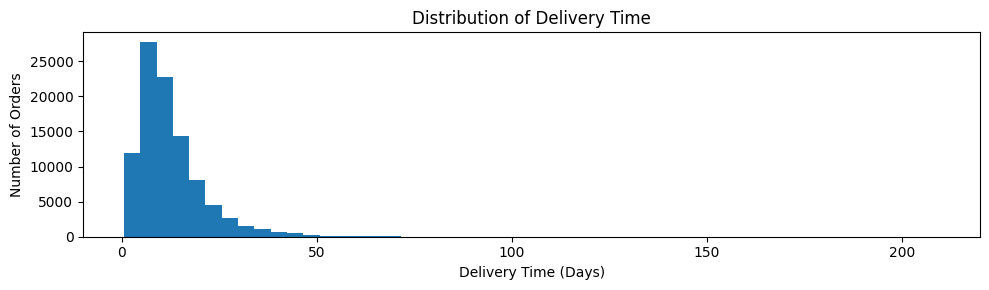

In [15]:
plt.figure(figsize=(10, 3))

plt.hist(
    delivery["delivery_days"],
    bins=50
)

plt.xlabel("Delivery Time (Days)")
plt.ylabel("Number of Orders")
plt.title("Distribution of Delivery Time")

plt.tight_layout()
plt.show()

### Customer spending distribution

In [16]:
query = """
SELECT

    c.customer_unique_id,

    COUNT(DISTINCT o.order_id) AS orders,

    SUM(oi.price) AS total_spend

FROM customers AS c

JOIN orders AS o
    ON c.customer_id = o.customer_id

JOIN order_items AS oi
    ON o.order_id = oi.order_id

GROUP BY c.customer_unique_id;
"""

customer_value = pd.read_sql(query, engine)
display(customer_value.head())
print()
display(customer_value.describe())

,customer_unique_id,orders,total_spend
0,0000366f3b9a7992bf8c76cfdf3221e2,1,129.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,18.90
2,0000f46a3911fa3c0805444483337064,1,69.00
3,0000f6ccb0745a6a4b88665a16c9f078,1,25.99
4,0004aac84e0df4da2b147fca70cf8255,1,180.00


,orders,total_spend
count,95420.000000,95420.000000
mean,1.034018,142.440198
std,0.211234,217.656355
min,1.000000,0.850000
25%,1.000000,47.900000
50%,1.000000,89.900000
75%,1.000000,155.000000
max,16.000000,13440.000000


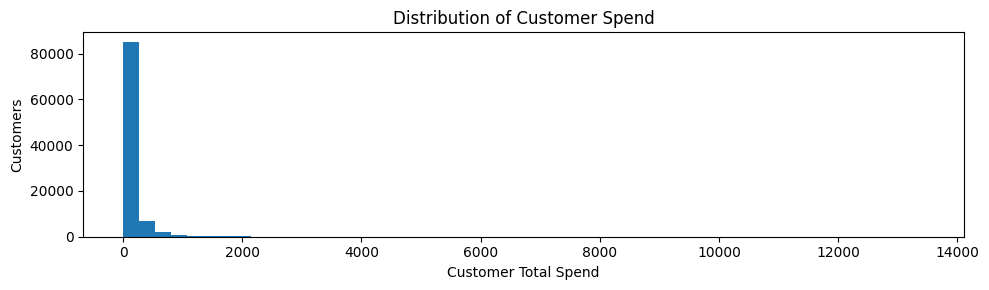

In [17]:
plt.figure(figsize=(10, 3))

plt.hist(
    customer_value["total_spend"],
    bins=50
)

plt.xlabel("Customer Total Spend")
plt.ylabel("Customers")
plt.title("Distribution of Customer Spend")

plt.tight_layout()
plt.show()

### RFM Segment Visualization

In [18]:
query = """
WITH customer_metrics AS (

    SELECT
        c.customer_unique_id,

        MAX(o.order_purchase_timestamp::timestamp) AS last_purchase_date,

        COUNT(DISTINCT o.order_id) AS frequency,

        SUM(oi.price::numeric) AS monetary

    FROM customers AS c

    JOIN orders AS o
        ON c.customer_id = o.customer_id

    JOIN order_items AS oi
        ON o.order_id = oi.order_id

    GROUP BY c.customer_unique_id
),

reference_date AS (

    SELECT MAX(order_purchase_timestamp::timestamp) AS max_order_date
    FROM orders
)

SELECT
    cm.customer_unique_id,

    EXTRACT(
        DAY FROM (
            rd.max_order_date - cm.last_purchase_date
        )
    ) AS recency_days,

    cm.frequency,

    cm.monetary

FROM customer_metrics AS cm

CROSS JOIN reference_date AS rd;
"""

rfm = pd.read_sql(query, engine)
rfm.head()

,customer_unique_id,recency_days,frequency,monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,160.0,1,129.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,163.0,1,18.90
2,0000f46a3911fa3c0805444483337064,585.0,1,69.00
3,0000f6ccb0745a6a4b88665a16c9f078,369.0,1,25.99
4,0004aac84e0df4da2b147fca70cf8255,336.0,1,180.00


In [19]:
rfm["R_score"] = pd.qcut(
    rfm["recency_days"],
    5,
    labels=[5, 4, 3, 2, 1]
).astype(int)

rfm["F_score"] = pd.qcut(
    rfm["frequency"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

rfm["M_score"] = pd.qcut(
    rfm["monetary"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

In [20]:
def segment_customer(row):

    r = row["R_score"]
    f = row["F_score"]
    m = row["M_score"]

    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"

    elif r >= 4 and f >= 3:
        return "Loyal Customers"

    elif r >= 4 and f <= 2:
        return "Recent Customers"

    elif r <= 2 and f >= 3 and m >= 3:
        return "At Risk High Value"

    elif r <= 2:
        return "Inactive"

    else:
        return "Developing"


rfm["segment"] = rfm.apply(segment_customer, axis=1)

In [21]:
segment_summary = (
    rfm.groupby("segment")
    .agg(
        customers=("customer_unique_id", "count"),
        avg_frequency=("frequency", "mean"),
        avg_spend=("monetary", "mean"),
        total_spend=("monetary", "sum")
    )
    .sort_values("total_spend", ascending=False)
)

segment_summary

,customers,avg_frequency,avg_spend,total_spend
segment,,,,
At Risk High Value,13486,1.072371,216.869634,2924703.89
Developing,19126,1.035658,134.391737,2570376.36
Inactive,24490,1.005390,103.241698,2528389.18
Recent Customers,15335,1.000000,140.309217,2151641.85
Champions,6651,1.174861,277.028752,1842518.23
Loyal Customers,16332,1.017940,96.376083,1574014.19


## Hypothesis Testing

H0: Delivery span and status has no effects on customer review scores

H1: Late and On-time delivery have effects on customer review scores

In [23]:
# Making a test dataset

query = """
WITH delivery AS (

    SELECT
        order_id,

        CASE
            WHEN order_delivered_customer_date::timestamp
                 <= order_estimated_delivery_date::timestamp
            THEN 'On Time'

            ELSE 'Late'
        END AS delivery_status

    FROM orders

    WHERE order_delivered_customer_date IS NOT NULL
      AND order_estimated_delivery_date IS NOT NULL
),

reviews AS (

    SELECT
        order_id,
        AVG(review_score::numeric) AS review_score

    FROM order_reviews

    GROUP BY order_id
)

SELECT

    d.order_id,
    d.delivery_status,
    r.review_score

FROM delivery AS d

JOIN reviews AS r
    ON d.order_id = r.order_id;
"""

delivery_review = pd.read_sql(query, engine)

delivery_review.head()

,order_id,delivery_status,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,On Time,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,On Time,4.0
2,949d5b44dbf5de918fe9c16f97b45f8a,On Time,5.0
3,ad21c59c0840e6cb83a9ceb5573f8159,On Time,5.0
4,6514b8ad8028c9f2cc2374ded245783f,On Time,5.0


In [24]:
delivery_review.groupby(
    "delivery_status"
)["review_score"].agg(
    ["count", "mean", "median", "std"]
)

,count,mean,median,std
delivery_status,,,,
Late,7662,2.566562,2.0,1.657714
On Time,88168,4.294151,5.0,1.146214


#### Mann–Whitney U test

In [34]:
from scipy.stats import mannwhitneyu

on_time = delivery_review.loc[
    delivery_review["delivery_status"] == "On Time",
    "review_score"
]

late = delivery_review.loc[
    delivery_review["delivery_status"] == "Late",
    "review_score"
]

statistic, p_value = mannwhitneyu(
    on_time,
    late,
    alternative="two-sided"
)

print("Mann-Whitney U statistic:", statistic)
print("p-value:", p_value)

Mann-Whitney U statistic: 524826310.5
p-value: 0.0


Interpretation:

**p-value < 0.05 →** Review scores differ significantly between late and on-time deliveries

**p-value >= 0.05 →** Review scores do not differ significantly due to late or on-time deliveries

### Test: Delivery delay vs Review score

In [30]:
query = """
SELECT

    o.order_id,

    EXTRACT(
        EPOCH FROM (
            o.order_delivered_customer_date::timestamp
            - o.order_estimated_delivery_date::timestamp
        )
    ) / 86400.0 AS delay_days,

    r.review_score

FROM orders AS o

JOIN order_reviews AS r
    ON o.order_id = r.order_id

WHERE o.order_delivered_customer_date IS NOT NULL
  AND o.order_estimated_delivery_date IS NOT NULL;
"""

delay_review = pd.read_sql(query, engine)

delay_review.head()

,order_id,delay_days,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,-7.107488,4
1,53cdb2fc8bc7dce0b6741e2150273451,-5.355729,4
2,949d5b44dbf5de918fe9c16f97b45f8a,-12.980069,5
3,ad21c59c0840e6cb83a9ceb5573f8159,-9.238171,5
4,6514b8ad8028c9f2cc2374ded245783f,-11.461215,5


In [31]:
# Spearman correlation

delay_review[["delay_days", "review_score"]].corr(
    method="spearman"
)

,delay_days,review_score
delay_days,1.000000,-0.175612
review_score,-0.175612,1.000000


In [32]:
from scipy.stats import spearmanr

rho, p_value = spearmanr(
    delay_review["delay_days"],
    delay_review["review_score"]
)

print("Spearman correlation:", rho)
print("p-value:", p_value)

Spearman correlation: -0.1756117420557752
p-value: 0.0


Interpretation:  < Spearman correlation is rho \>

**rho < 0 →** greater delays tend to correspond to lower review scores.

**rho > 0 →** greater delays tend to correspond to higher review scores.

**rho ≈ 0 →** little monotonic association.

Therefore, delivery delay has a statistically significant negative association with review score

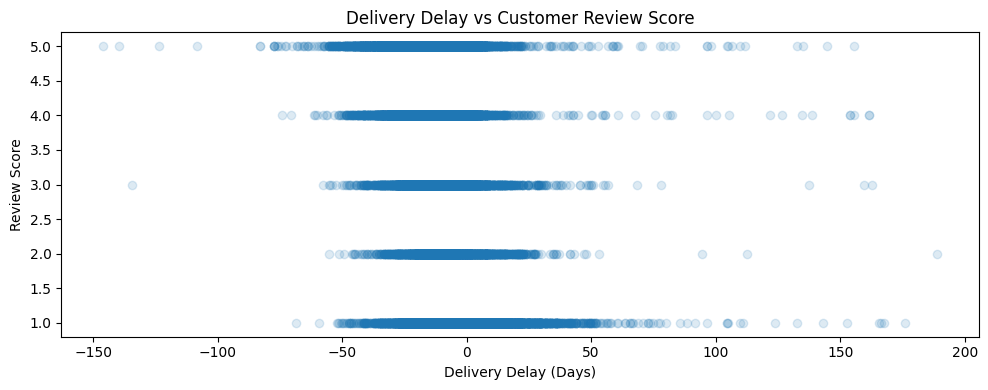

In [36]:
plt.figure(figsize=(10, 4))

plt.scatter(
    delay_review["delay_days"],
    delay_review["review_score"],
    alpha=0.15
)

plt.xlabel("Delivery Delay (Days)")
plt.ylabel("Review Score")
plt.title("Delivery Delay vs Customer Review Score")

plt.tight_layout()
plt.show()

### Category Concentration

In [38]:
query = """
SELECT

    COALESCE(
        pc.product_category_name_english,
        p.product_category_name,
        'Unknown'
    ) AS category,

    SUM(oi.price::numeric) AS product_sales

FROM order_items AS oi

JOIN products AS p
    ON oi.product_id = p.product_id

LEFT JOIN product_category AS pc
    ON p.product_category_name = pc.product_category_name

GROUP BY 1
ORDER BY product_sales DESC;
"""

category_sales = pd.read_sql(query, engine)
category_sales

,category,product_sales
0,health_beauty,1258681.34
1,watches_gifts,1205005.68
2,bed_bath_table,1036988.68
3,sports_leisure,988048.97
4,computers_accessories,911954.32
...,...,...
66,flowers,1110.04
67,home_comfort_2,760.27
68,cds_dvds_musicals,730.00
69,fashion_childrens_clothes,569.85


In [39]:
category_sales["sales_share_pct"] = (
    category_sales["product_sales"]
    / category_sales["product_sales"].sum()
    * 100
)

In [40]:
category_sales["cumulative_sales_pct"] = (
    category_sales["sales_share_pct"].cumsum()
)

category_sales.head(20)

,category,product_sales,sales_share_pct,cumulative_sales_pct
0,health_beauty,1258681.34,9.388524,9.388524
1,watches_gifts,1205005.68,8.988157,18.376681
2,bed_bath_table,1036988.68,7.734915,26.111596
3,sports_leisure,988048.97,7.369873,33.481470
4,computers_accessories,911954.32,6.802282,40.283752
5,furniture_decor,729762.49,5.443310,45.727062
6,cool_stuff,635290.85,4.738645,50.465706
7,housewares,632248.66,4.715953,55.181659
8,auto,592720.11,4.421109,59.602768
9,garden_tools,485256.46,3.619536,63.222304


In [42]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

fig = make_subplots(rows=2, cols=1,
                    shared_xaxes=True,
                    vertical_spacing=0.1,
                    subplot_titles=("Cumulative Sales Percentage by Category", "Category Sales Share Percentage"))

# Line graph for cumulative growth
fig.add_trace(go.Scatter(x=category_sales["category"], y=category_sales["cumulative_sales_pct"], mode='lines+markers', name='Cumulative Sales %'),
              row=1, col=1)

# Bar chart for category share percent
fig.add_trace(go.Bar(x=category_sales["category"], y=category_sales["sales_share_pct"], name='Sales Share %'),
              row=2, col=1)

fig.update_layout(height=800, title_text="Category Sales Analysis",
                  xaxis2={"tickangle": -45}, # Rotate x-axis labels for readability on the second plot
                  yaxis_title_text='Percentage', yaxis2_title_text='Percentage')

fig.show()

## Key Findings

### 1. Order values are highly right-skewed
Order-level product sales show substantial dispersion, with a median product sales value of approximately 86.90 compared with a mean of approximately 137.75. The maximum order value reaches 13,440, indicating that a relatively small number of high-value orders materially influence average order metrics.

**Implication:** Median-based metrics and percentile analysis should complement averages when evaluating order economics, as the customer/order value distribution is heavily skewed.

---

### 2. Delivery performance shows substantial variability
Delivery time is highly dispersed. The median delivery time is approximately 10.22 days, while the 75th, 90th, 95th and 99th percentiles are approximately 15.72, 23.10, 29.28 and 46.05 days respectively.

**Implication:** Average delivery time alone can hide the long tail of delayed fulfillment. Monitoring higher percentiles is important for identifying operational reliability issues and extreme customer experiences.

---

### 3. Customer spending is concentrated among a relatively small group
Customer-level spending is highly skewed. The median customer spend is approximately 89.90, compared with a mean of approximately 142.44. Customers place an average of approximately 1.03 orders, while the maximum observed customer frequency is 16 orders.

**Implication:** The customer base is dominated by low-frequency purchasers, while a smaller group of customers contributes substantially more value. Retention and repeat-purchase strategies therefore represent an important opportunity.

---

### 4. Customer purchase behavior is predominantly one-time
Customer-level order frequency is strongly concentrated at one purchase, with the median customer placing a single order. Although repeat purchasers exist, they represent a much smaller portion of the overall customer base.

**Implication:** Improving repeat purchase behavior could be an important lever for increasing customer lifetime value and reducing dependence on continuous acquisition.

---

### 5. Sales are concentrated across a relatively small number of product categories
Product-category analysis shows meaningful concentration in marketplace sales. The largest category, `health_beauty`, contributes approximately 9.39% of product sales, while the seven largest categories together account for approximately 50.47% of product sales.

**Implication:** A relatively small group of categories represents a substantial portion of marketplace sales, making category-level assortment, inventory and seller strategy particularly important.

---

### 6. Delivery performance is strongly associated with customer satisfaction
Orders delivered late have substantially lower customer review scores than orders delivered on time. The mean review score is approximately 2.57 for late deliveries compared with approximately 4.29 for on-time deliveries.

A Mann–Whitney U test indicates that the difference between the two groups is statistically significant (p < 0.001).

**Implication:** Delivery reliability is strongly associated with customer experience. Improving fulfillment performance should therefore be considered not only an operational objective but also a customer-retention objective.

---

### 7. Greater delivery delays are associated with lower review scores
Spearman correlation analysis indicates a statistically significant negative association between delivery delay and review score (ρ ≈ −0.176, p < 0.001).

The relationship is statistically significant but moderate in magnitude, indicating that delivery delay is an important factor in customer satisfaction but is not the sole determinant of review outcomes.

**Implication:** Reducing delivery delays may improve customer experience, but other factors such as product quality, seller performance and service experience should also be considered.

---

### 8. Customer segmentation reveals different strategic priorities
RFM analysis identifies distinct customer groups based on recency, frequency and monetary value, including Champions, Loyal Customers, Recent Customers, At Risk High Value, Inactive and Developing customers.

**Implication:** A single retention strategy is unlikely to be optimal across the customer base. High-value customers at risk of inactivity should receive different treatment from recent or developing customers, while Champions and Loyal Customers represent opportunities for retention and advocacy.

## Business Implications & Recommendations

Based on the combined sales, customer and operational analysis, the following actions are recommended:

### 1. Prioritize fulfillment reliability
Late delivery is strongly associated with lower customer review scores. Operational teams should monitor late-delivery rates and delivery-time percentiles by seller, geography and product category to identify recurring bottlenecks.

### 2. Develop targeted retention strategies
The strong concentration of customers around a single purchase suggests an opportunity to increase repeat purchasing. Recent customers can be targeted with relevant follow-up offers, while high-value customers showing declining engagement should receive higher-priority retention interventions.

### 3. Protect high-value customer segments
RFM segmentation provides a framework for prioritizing customers. Champions and Loyal Customers should be retained through consistent service and relevant engagement, while At Risk High Value customers warrant targeted reactivation efforts.

### 4. Focus category-level decision making
Sales concentration across a relatively small number of categories suggests that category performance should be monitored closely. High-contribution categories can receive greater assortment and seller attention, while weaker categories should be evaluated for pricing, demand and product-quality issues.

### 5. Monitor operational performance beyond averages
Because both order values and delivery times exhibit long-tailed distributions, operational dashboards should include median and percentile-based metrics rather than relying exclusively on averages. This provides a more realistic view of typical and extreme customer experiences.

## Analytical Conclusion

The analysis indicates that Olist's marketplace performance is characterized by concentrated sales, predominantly one-time customer behavior, substantial variation in order and delivery values, and a strong relationship between fulfillment performance and customer satisfaction.

The most actionable opportunity identified is the connection between **operational reliability and customer experience**. While delivery performance is not the only determinant of customer satisfaction, the statistically significant difference in review scores between late and on-time deliveries suggests that fulfillment reliability should be treated as a key customer-experience metric.

These findings form the basis for the interactive Power BI dashboard developed in the next stage of the project.